In [1]:
# ============================================================
# PROJECT 2 — LINEAR REGRESSION
# AI ADOPTION AND SUBSEQUENT REVENUE OUTCOMES
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [9]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 2 — LOAD THE ORIGINAL EXCEL DATA
# ============================================================

file_path = r"C:\Users\McCaiT01\OneDrive - CPGPLC\Misc\Code\DTSC Studio 2\Sector by Employment Size Class.xlsx"

df = pd.read_excel(file_path)

print("Original dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Original dataset shape: (11622, 85)

Columns:
['Sector', 'Empsize', 'Question ID', 'Question', 'Answer ID', 'Answer', '202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610', '202609', '202608', '202607', '202606', '202605', '202604', '202603', '202602', '202601', '202526', '202525', '202524', '202523', '202522', '202521', '202520', '202519', '202518', '202517', '202516', '202515', '202514', '202513', '202512', '202511', '202510', '202509', '202508', '202507', '202506', '202505', '202504', '202503', '202502', '202501', '202426', '202425', '202424', '202423', '202422', '202421', '202420', '202419', '202418', '202417', '202416', '202415', '202414', '202413', '202412', '202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']

First 5 rows:


,Sector,Empsize,Question ID,Question,Answer ID,Answer,202619,202618,202617,202616,...,202402,202401,202326,202325,202324,202323,202322,202321,202320,202319
0,11,A,3.0,"Overall, how would you describe this business'...",1.0,Excellent,9.3%,S,S,S,...,10.2%,10.8%,12.4%,12.9%,18.9%,7.5%,9.2%,15.5%,9.3%,14.8%
1,11,A,3.0,"Overall, how would you describe this business'...",2.0,Above average,27.1%,S,15.2%,22.2%,...,10.5%,15.4%,15.2%,18.3%,10.7%,22.9%,21.2%,15.1%,18.3%,18.3%
2,11,A,3.0,"Overall, how would you describe this business'...",3.0,Average,48.7%,62.0%,45.7%,52.7%,...,55.7%,53.8%,53.0%,46.5%,51.6%,44.5%,41.6%,42.4%,57.6%,46.4%
3,11,A,3.0,"Overall, how would you describe this business'...",4.0,Below average,S,17.4%,32.4%,13.3%,...,18.2%,14.9%,6.2%,13.1%,8.8%,18.6%,14.7%,13.2%,9.1%,18.6%
4,11,A,3.0,"Overall, how would you describe this business'...",5.0,Poor,S,S,S,S,...,5.4%,S,13.2%,S,10.0%,6.6%,13.4%,13.7%,5.6%,S


In [10]:
# ============================================================
# STEP 3 — CHECK THE RAW DATA STRUCTURE
# ============================================================

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nQuestion IDs:")
print(df["Question ID"].dropna().unique())

print("\nAnswers:")
print(df["Answer"].dropna().unique())

Dataset shape: (11622, 85)

Columns:
['Sector', 'Empsize', 'Question ID', 'Question', 'Answer ID', 'Answer', '202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610', '202609', '202608', '202607', '202606', '202605', '202604', '202603', '202602', '202601', '202526', '202525', '202524', '202523', '202522', '202521', '202520', '202519', '202518', '202517', '202516', '202515', '202514', '202513', '202512', '202511', '202510', '202509', '202508', '202507', '202506', '202505', '202504', '202503', '202502', '202501', '202426', '202425', '202424', '202423', '202422', '202421', '202420', '202419', '202418', '202417', '202416', '202415', '202414', '202413', '202412', '202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']

Question IDs:
[ 3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20.
 21. 22. 23. 

In [11]:
# ============================================================
# STEP 4 — EXTRACT REVENUE AND AI DATA
# ============================================================

# Revenue question = Question 4
# AI question = Question 7

revenue = df[df["Question ID"] == 4.0].copy()

ai = df[df["Question ID"] == 7.0].copy()

print("Revenue rows:", len(revenue))
print("AI rows:", len(ai))

print("\nRevenue answers:")
print(revenue["Answer"].dropna().unique())

print("\nAI answers:")
print(ai["Answer"].dropna().unique())

Revenue rows: 420
AI rows: 420

Revenue answers:
<StringArray>
['Increased', 'Decreased', 'No change']
Length: 3, dtype: str

AI answers:
<StringArray>
['Yes', 'No', 'Do not know']
Length: 3, dtype: str


In [12]:
# ============================================================
# STEP 5 — IDENTIFY SURVEY PERIOD COLUMNS
# ============================================================

id_columns = [
    "Sector",
    "Empsize",
    "Question ID",
    "Question",
    "Answer"
]

period_columns = [
    col for col in df.columns
    if str(col).isdigit()
]

print("Number of survey periods:", len(period_columns))

print("\nFirst periods:")
print(period_columns[:10])

print("\nLast periods:")
print(period_columns[-10:])

Number of survey periods: 79

First periods:
['202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610']

Last periods:
['202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']


In [13]:
# ============================================================
# STEP 5 — IDENTIFY SURVEY PERIOD COLUMNS
# ============================================================

id_columns = [
    "Sector",
    "Empsize",
    "Question ID",
    "Question",
    "Answer"
]

period_columns = [
    col for col in df.columns
    if str(col).isdigit()
]

print("Number of survey periods:", len(period_columns))

print("\nFirst periods:")
print(period_columns[:10])

print("\nLast periods:")
print(period_columns[-10:])

Number of survey periods: 79

First periods:
['202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610']

Last periods:
['202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']


In [14]:
# ============================================================
# STEP 7 — CREATE REVENUE PERCENTAGE DATA
# ============================================================

revenue_wide = (
    revenue
    .pivot_table(
        index=["Sector", "Empsize"],
        columns="Answer",
        values=period_columns,
        aggfunc="first"
    )
)

print("Revenue wide shape:", revenue_wide.shape)

Revenue wide shape: (140, 237)


In [15]:
# ============================================================
# STEP 7 — CREATE REVENUE PERCENTAGE DATA
# ============================================================

revenue_wide = (
    revenue
    .pivot_table(
        index=["Sector", "Empsize"],
        columns="Answer",
        values=period_columns,
        aggfunc="first"
    )
)

print("Revenue wide shape:", revenue_wide.shape)

Revenue wide shape: (140, 237)


In [16]:
# ============================================================
# STEP 9 — CREATE AI ADOPTION DATA
# ============================================================

ai_yes = ai[ai["Answer"] == "Yes"].copy()

ai_yes = ai_yes[
    ["Sector", "Empsize"] + period_columns
].copy()

ai_yes = ai_yes.rename(
    columns={
        period: f"{period}_AI_Yes_Percentage"
        for period in period_columns
    }
)

print("AI adoption dataset shape:", ai_yes.shape)

display(ai_yes.head())

AI adoption dataset shape: (140, 81)


,Sector,Empsize,202619_AI_Yes_Percentage,202618_AI_Yes_Percentage,202617_AI_Yes_Percentage,202616_AI_Yes_Percentage,202615_AI_Yes_Percentage,202614_AI_Yes_Percentage,202613_AI_Yes_Percentage,202612_AI_Yes_Percentage,...,202402_AI_Yes_Percentage,202401_AI_Yes_Percentage,202326_AI_Yes_Percentage,202325_AI_Yes_Percentage,202324_AI_Yes_Percentage,202323_AI_Yes_Percentage,202322_AI_Yes_Percentage,202321_AI_Yes_Percentage,202320_AI_Yes_Percentage,202319_AI_Yes_Percentage
14,11,A,S,S,S,14.8%,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
97,11,B,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
180,11,C,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
263,11,D,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
346,11,E,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.


In [17]:
# ============================================================
# STEP 9 — CREATE AI ADOPTION DATA
# ============================================================

ai_yes = ai[ai["Answer"] == "Yes"].copy()

ai_yes = ai_yes[
    ["Sector", "Empsize"] + period_columns
].copy()

ai_yes = ai_yes.rename(
    columns={
        period: f"{period}_AI_Yes_Percentage"
        for period in period_columns
    }
)

print("AI adoption dataset shape:", ai_yes.shape)

display(ai_yes.head())

AI adoption dataset shape: (140, 81)


,Sector,Empsize,202619_AI_Yes_Percentage,202618_AI_Yes_Percentage,202617_AI_Yes_Percentage,202616_AI_Yes_Percentage,202615_AI_Yes_Percentage,202614_AI_Yes_Percentage,202613_AI_Yes_Percentage,202612_AI_Yes_Percentage,...,202402_AI_Yes_Percentage,202401_AI_Yes_Percentage,202326_AI_Yes_Percentage,202325_AI_Yes_Percentage,202324_AI_Yes_Percentage,202323_AI_Yes_Percentage,202322_AI_Yes_Percentage,202321_AI_Yes_Percentage,202320_AI_Yes_Percentage,202319_AI_Yes_Percentage
14,11,A,S,S,S,14.8%,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
97,11,B,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
180,11,C,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
263,11,D,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
346,11,E,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.


In [24]:
# ============================================================
# STEPS 10–13 — REBUILD REVENUE PERCENTAGE DATA
# ============================================================

# ------------------------------------------------------------
# STEP 10 — Inspect the original revenue dataframe
# ------------------------------------------------------------

print("Revenue dataframe shape:", revenue.shape)
print("\nRevenue columns:")
print(revenue.columns.tolist()[:30])

print("\nFirst few rows:")
display(revenue.head())


# ------------------------------------------------------------
# STEP 11 — IDENTIFY REVENUE PERCENTAGE COLUMNS
# ------------------------------------------------------------

# Find columns that contain the three revenue categories.
revenue_increased_cols = [
    col for col in revenue.columns
    if "Increased" in str(col)
]

revenue_decreased_cols = [
    col for col in revenue.columns
    if "Decreased" in str(col)
]

revenue_no_change_cols = [
    col for col in revenue.columns
    if "No change" in str(col) or "No Change" in str(col)
]

print("\nRevenue Increased columns:")
print(revenue_increased_cols[:10])

print("\nRevenue Decreased columns:")
print(revenue_decreased_cols[:10])

print("\nRevenue No Change columns:")
print(revenue_no_change_cols[:10])


# ------------------------------------------------------------
# STEP 12 — CONVERT REVENUE DATA FROM WIDE TO LONG FORMAT
# ------------------------------------------------------------

# We expect columns to look something like:
#
# 202619_Increased
# 202619_Decreased
# 202619_No change
#
# or similar.
#
# Instead of assuming the exact names, we extract the
# period and category from the column names.

revenue_records = []

for col in revenue.columns:

    col_str = str(col)

    # Skip identifier columns
    if col_str in ["Sector", "Empsize"]:
        continue

    # Determine revenue category
    if "Increased" in col_str:
        category = "Increased"

    elif "Decreased" in col_str:
        category = "Decreased"

    elif "No change" in col_str or "No Change" in col_str:
        category = "No change"

    else:
        continue

    # Extract the period from the beginning of the column name
    period = col_str.split("_")[0]

    # Keep only columns whose first component looks like a period
    if not period.isdigit():
        continue

    temp = revenue[
        ["Sector", "Empsize", col]
    ].copy()

    temp["Period"] = period
    temp["Revenue_Category"] = category

    temp = temp.rename(columns={col: "Percentage"})

    revenue_records.append(temp)


# Combine everything
if len(revenue_records) == 0:
    raise ValueError(
        "No revenue percentage columns were found. "
        "Print revenue.columns.tolist() and inspect the actual column names."
    )

revenue_long = pd.concat(
    revenue_records,
    ignore_index=True
)

print("\nRevenue long-format shape:", revenue_long.shape)

print("\nRevenue categories:")
print(revenue_long["Revenue_Category"].value_counts())

print("\nFirst 10 observations:")
display(revenue_long.head(10))


# ------------------------------------------------------------
# STEP 13 — PIVOT INTO ONE ROW PER
# SECTOR / EMPLOYMENT SIZE / PERIOD
# ------------------------------------------------------------

revenue_pct = (
    revenue_long
    .pivot_table(
        index=["Sector", "Empsize", "Period"],
        columns="Revenue_Category",
        values="Percentage",
        aggfunc="first"
    )
    .reset_index()
)

# Remove the pivot column name
revenue_pct.columns.name = None


# Rename columns
revenue_pct = revenue_pct.rename(
    columns={
        "Increased": "Revenue_Increased_Percentage",
        "Decreased": "Revenue_Decreased_Percentage",
        "No change": "Revenue_No_Change_Percentage"
    }
)

# Make sure all expected columns exist
expected_revenue_cols = [
    "Revenue_Increased_Percentage",
    "Revenue_Decreased_Percentage",
    "Revenue_No_Change_Percentage"
]

for col in expected_revenue_cols:
    if col not in revenue_pct.columns:
        revenue_pct[col] = np.nan


# Convert percentages to numeric
for col in expected_revenue_cols:

    revenue_pct[col] = (
        revenue_pct[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace({
            "S": np.nan,
            ".": np.nan,
            "": np.nan,
            "nan": np.nan
        })
    )

    revenue_pct[col] = pd.to_numeric(
        revenue_pct[col],
        errors="coerce"
    )


print("\nRevenue percentage dataset shape:", revenue_pct.shape)

print("\nColumns:")
print(revenue_pct.columns.tolist())

print("\nMissing values:")
print(revenue_pct[expected_revenue_cols].isna().sum())

print("\nFirst 10 observations:")
display(revenue_pct.head(10))

Revenue dataframe shape: (420, 85)

Revenue columns:
['Sector', 'Empsize', 'Question ID', 'Question', 'Answer ID', 'Answer', '202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610', '202609', '202608', '202607', '202606', '202605', '202604', '202603', '202602', '202601', '202526', '202525', '202524', '202523', '202522']

First few rows:


,Sector,Empsize,Question ID,Question,Answer ID,Answer,202619,202618,202617,202616,...,202402,202401,202326,202325,202324,202323,202322,202321,202320,202319
5,11,A,4.0,"In the last two weeks, how did this business's...",1.0,Increased,16.5%,S,S,12.5%,...,S,S,12.4%,9.6%,4.9%,S,5.3%,13.8%,16.4%,S
6,11,A,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,29.0%,34.3%,24.3%,18.7%,...,17.7%,40.0%,34.4%,37.2%,24.4%,35.9%,35.2%,29.5%,30.2%,28.1%
7,11,A,4.0,"In the last two weeks, how did this business's...",3.0,No change,54.5%,62.0%,65.5%,68.8%,...,77.9%,54.3%,53.2%,53.2%,70.7%,55.3%,59.5%,56.7%,53.4%,68.1%
88,11,B,4.0,"In the last two weeks, how did this business's...",1.0,Increased,S,S,S,S,...,S,S,S,S,S,S,S,S,S,12.5%
89,11,B,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,39.7%,S,S,46.1%,...,S,17.2%,48.9%,28.2%,20.9%,36.5%,S,31.1%,33.0%,39.0%



Revenue Increased columns:
[]

Revenue Decreased columns:
[]

Revenue No Change columns:
[]


ValueError: No revenue percentage columns were found. Print revenue.columns.tolist() and inspect the actual column names.

In [25]:
# ============================================================
# REVENUE DATA DIAGNOSTIC
# ============================================================

print("Revenue shape:", revenue.shape)

print("\nALL REVENUE COLUMNS:")
for i, col in enumerate(revenue.columns):
    print(i, repr(col))

print("\nFIRST 5 ROWS:")
display(revenue.head())

Revenue shape: (420, 85)

ALL REVENUE COLUMNS:
0 'Sector'
1 'Empsize'
2 'Question ID'
3 'Question'
4 'Answer ID'
5 'Answer'
6 '202619'
7 '202618'
8 '202617'
9 '202616'
10 '202615'
11 '202614'
12 '202613'
13 '202612'
14 '202611'
15 '202610'
16 '202609'
17 '202608'
18 '202607'
19 '202606'
20 '202605'
21 '202604'
22 '202603'
23 '202602'
24 '202601'
25 '202526'
26 '202525'
27 '202524'
28 '202523'
29 '202522'
30 '202521'
31 '202520'
32 '202519'
33 '202518'
34 '202517'
35 '202516'
36 '202515'
37 '202514'
38 '202513'
39 '202512'
40 '202511'
41 '202510'
42 '202509'
43 '202508'
44 '202507'
45 '202506'
46 '202505'
47 '202504'
48 '202503'
49 '202502'
50 '202501'
51 '202426'
52 '202425'
53 '202424'
54 '202423'
55 '202422'
56 '202421'
57 '202420'
58 '202419'
59 '202418'
60 '202417'
61 '202416'
62 '202415'
63 '202414'
64 '202413'
65 '202412'
66 '202411'
67 '202410'
68 '202409'
69 '202408'
70 '202407'
71 '202406'
72 '202405'
73 '202404'
74 '202403'
75 '202402'
76 '202401'
77 '202326'
78 '202325'
79 '

,Sector,Empsize,Question ID,Question,Answer ID,Answer,202619,202618,202617,202616,...,202402,202401,202326,202325,202324,202323,202322,202321,202320,202319
5,11,A,4.0,"In the last two weeks, how did this business's...",1.0,Increased,16.5%,S,S,12.5%,...,S,S,12.4%,9.6%,4.9%,S,5.3%,13.8%,16.4%,S
6,11,A,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,29.0%,34.3%,24.3%,18.7%,...,17.7%,40.0%,34.4%,37.2%,24.4%,35.9%,35.2%,29.5%,30.2%,28.1%
7,11,A,4.0,"In the last two weeks, how did this business's...",3.0,No change,54.5%,62.0%,65.5%,68.8%,...,77.9%,54.3%,53.2%,53.2%,70.7%,55.3%,59.5%,56.7%,53.4%,68.1%
88,11,B,4.0,"In the last two weeks, how did this business's...",1.0,Increased,S,S,S,S,...,S,S,S,S,S,S,S,S,S,12.5%
89,11,B,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,39.7%,S,S,46.1%,...,S,17.2%,48.9%,28.2%,20.9%,36.5%,S,31.1%,33.0%,39.0%


In [26]:
# ============================================================
# STEPS 10–13 — PREPARE REVENUE PERCENTAGES
# ============================================================

# ------------------------------------------------------------
# STEP 10 — IDENTIFY REVENUE ANSWER CATEGORIES
# ------------------------------------------------------------

print("Unique revenue answers:")

print(
    revenue["Answer"]
    .dropna()
    .astype(str)
    .unique()
)


# ------------------------------------------------------------
# STEP 11 — KEEP THE REVENUE ANSWER CATEGORIES
# ------------------------------------------------------------

# Clean the Answer column
revenue["Answer_Clean"] = (
    revenue["Answer"]
    .astype(str)
    .str.strip()
)

print("\nRevenue answer distribution:")

print(
    revenue["Answer_Clean"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# STEP 12 — CONVERT REVENUE DATA TO LONG FORMAT
# ------------------------------------------------------------

# These are the period columns.
# A period is a numeric column name such as 202619.

period_cols = [
    col for col in revenue.columns
    if str(col).isdigit()
]

print("\nNumber of period columns:", len(period_cols))
print("First periods:", period_cols[:10])
print("Last periods:", period_cols[-10:])


# Melt the revenue dataset.
#
# Each row will become:
# Sector | Empsize | Answer | Period | Percentage

revenue_long = revenue.melt(
    id_vars=[
        "Sector",
        "Empsize",
        "Question ID",
        "Question",
        "Answer ID",
        "Answer",
        "Answer_Clean"
    ],
    value_vars=period_cols,
    var_name="Period",
    value_name="Percentage"
)

print("\nRevenue long-format shape:")
print(revenue_long.shape)

print("\nFirst 10 observations:")
display(revenue_long.head(10))


# ------------------------------------------------------------
# STEP 13 — IDENTIFY THE THREE REVENUE CATEGORIES
# ------------------------------------------------------------

# First, inspect the actual answer labels.
print("\nUnique Answer_Clean values:")
print(
    sorted(
        revenue_long["Answer_Clean"]
        .dropna()
        .unique()
    )
)

Unique revenue answers:
<StringArray>
['Increased', 'Decreased', 'No change']
Length: 3, dtype: str

Revenue answer distribution:
Answer_Clean
Increased    140
Decreased    140
No change    140
Name: count, dtype: int64

Number of period columns: 79
First periods: ['202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610']
Last periods: ['202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']

Revenue long-format shape:
(33180, 9)

First 10 observations:


,Sector,Empsize,Question ID,Question,Answer ID,Answer,Answer_Clean,Period,Percentage
0,11,A,4.0,"In the last two weeks, how did this business's...",1.0,Increased,Increased,202619,16.5%
1,11,A,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,Decreased,202619,29.0%
2,11,A,4.0,"In the last two weeks, how did this business's...",3.0,No change,No change,202619,54.5%
3,11,B,4.0,"In the last two weeks, how did this business's...",1.0,Increased,Increased,202619,S
4,11,B,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,Decreased,202619,39.7%
5,11,B,4.0,"In the last two weeks, how did this business's...",3.0,No change,No change,202619,51.6%
6,11,C,4.0,"In the last two weeks, how did this business's...",1.0,Increased,Increased,202619,S
7,11,C,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,Decreased,202619,S
8,11,C,4.0,"In the last two weeks, how did this business's...",3.0,No change,No change,202619,86.6%
9,11,D,4.0,"In the last two weeks, how did this business's...",1.0,Increased,Increased,202619,S



Unique Answer_Clean values:
['Decreased', 'Increased', 'No change']


In [27]:
# ============================================================
# STEP 14 — CREATE REVENUE PERCENTAGE DATASET
# ============================================================

# Convert percentage strings to numeric values
revenue_long["Percentage"] = (
    revenue_long["Percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
    .replace({
        "S": np.nan,
        ".": np.nan,
        "": np.nan,
        "nan": np.nan
    })
)

revenue_long["Percentage"] = pd.to_numeric(
    revenue_long["Percentage"],
    errors="coerce"
)

# Create one row per Sector / Empsize / Period
revenue_pct = (
    revenue_long
    .pivot_table(
        index=["Sector", "Empsize", "Period"],
        columns="Answer_Clean",
        values="Percentage",
        aggfunc="first"
    )
    .reset_index()
)

revenue_pct.columns.name = None

# Rename columns
revenue_pct = revenue_pct.rename(
    columns={
        "Increased": "Revenue_Increased_Percentage",
        "Decreased": "Revenue_Decreased_Percentage",
        "No change": "Revenue_No_Change_Percentage"
    }
)

print("Revenue percentage dataset shape:")
print(revenue_pct.shape)

print("\nColumns:")
print(revenue_pct.columns.tolist())

print("\nMissing values:")
print(
    revenue_pct[
        [
            "Revenue_Increased_Percentage",
            "Revenue_Decreased_Percentage",
            "Revenue_No_Change_Percentage"
        ]
    ].isna().sum()
)

print("\nFirst 10 observations:")
display(revenue_pct.head(10))

Revenue percentage dataset shape:
(9449, 6)

Columns:
['Sector', 'Empsize', 'Period', 'Revenue_Decreased_Percentage', 'Revenue_Increased_Percentage', 'Revenue_No_Change_Percentage']

Missing values:
Revenue_Increased_Percentage    1802
Revenue_Decreased_Percentage    1788
Revenue_No_Change_Percentage     146
dtype: int64

First 10 observations:


,Sector,Empsize,Period,Revenue_Decreased_Percentage,Revenue_Increased_Percentage,Revenue_No_Change_Percentage
0,11,A,202319,28.1,NaN,68.1
1,11,A,202320,30.2,16.4,53.4
2,11,A,202321,29.5,13.8,56.7
3,11,A,202322,35.2,5.3,59.5
4,11,A,202323,35.9,NaN,55.3
5,11,A,202324,24.4,4.9,70.7
6,11,A,202325,37.2,9.6,53.2
7,11,A,202326,34.4,12.4,53.2
8,11,A,202401,40.0,NaN,54.3
9,11,A,202402,17.7,NaN,77.9


In [28]:
# ============================================================
# STEP 15 — CREATE CONTINUOUS REVENUE CHANGE TARGET
# ============================================================

revenue_pct["Revenue_Change_Score"] = (
    revenue_pct["Revenue_Increased_Percentage"]
    - revenue_pct["Revenue_Decreased_Percentage"]
)

print("Revenue Change Score summary:")
print(
    revenue_pct["Revenue_Change_Score"].describe()
)

print("\nMissing Revenue Change Scores:")
print(
    revenue_pct["Revenue_Change_Score"].isna().sum()
)

print("\nFirst 10 observations:")
display(
    revenue_pct[
        [
            "Sector",
            "Empsize",
            "Period",
            "Revenue_Increased_Percentage",
            "Revenue_Decreased_Percentage",
            "Revenue_No_Change_Percentage",
            "Revenue_Change_Score"
        ]
    ].head(10)
)

Revenue Change Score summary:
count    6947.000000
mean       -9.957334
std        12.426831
min       -51.300000
25%       -18.600000
50%       -10.500000
75%        -1.500000
max        35.700000
Name: Revenue_Change_Score, dtype: float64

Missing Revenue Change Scores:
2502

First 10 observations:


,Sector,Empsize,Period,Revenue_Increased_Percentage,Revenue_Decreased_Percentage,Revenue_No_Change_Percentage,Revenue_Change_Score
0,11,A,202319,NaN,28.1,68.1,NaN
1,11,A,202320,16.4,30.2,53.4,-13.8
2,11,A,202321,13.8,29.5,56.7,-15.7
3,11,A,202322,5.3,35.2,59.5,-29.9
4,11,A,202323,NaN,35.9,55.3,NaN
5,11,A,202324,4.9,24.4,70.7,-19.5
6,11,A,202325,9.6,37.2,53.2,-27.6
7,11,A,202326,12.4,34.4,53.2,-22.0
8,11,A,202401,NaN,40.0,54.3,NaN
9,11,A,202402,NaN,17.7,77.9,NaN


In [32]:
# ============================================================
# DIAGNOSTIC — FIND EXISTING DATAFRAMES
# ============================================================

dataframes = [
    (name, obj.copy())
    for name, obj in list(globals().items())
    if isinstance(obj, pd.DataFrame)
]

print("DataFrames currently available:\n")

for name, df in dataframes:
    print(f"{name}: shape = {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("-" * 70)

DataFrames currently available:

df: shape = (11622, 85)
Columns: ['Sector', 'Empsize', 'Question ID', 'Question', 'Answer ID', 'Answer', '202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610', '202609', '202608', '202607', '202606', '202605', '202604', '202603', '202602', '202601', '202526', '202525', '202524', '202523', '202522', '202521', '202520', '202519', '202518', '202517', '202516', '202515', '202514', '202513', '202512', '202511', '202510', '202509', '202508', '202507', '202506', '202505', '202504', '202503', '202502', '202501', '202426', '202425', '202424', '202423', '202422', '202421', '202420', '202419', '202418', '202417', '202416', '202415', '202414', '202413', '202412', '202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']
----------------------------------------------------------------------
r

In [35]:

# ============================================================
# STEP 14 — CREATE THE REGRESSION DATASET
# CORRECTED FOR THE ACTUAL AI COLUMN NAMES
# ============================================================

print("Starting corrected Step 14...")

# ============================================================
# 1. FIND THE AI PERIOD COLUMNS
# ============================================================

# Your AI columns look like:
# 202619_AI_Yes_Percentage
# 202618_AI_Yes_Percentage
# 202617_AI_Yes_Percentage
# etc.

ai_period_columns = [
    col for col in ai_yes.columns
    if str(col).endswith("_AI_Yes_Percentage")
]

print("Number of AI period columns:", len(ai_period_columns))

print("\nFirst 5 AI columns:")
print(ai_period_columns[:5])

print("\nLast 5 AI columns:")
print(ai_period_columns[-5:])


# ============================================================
# 2. RESHAPE AI DATA FROM WIDE TO LONG
# ============================================================

ai_reg = ai_yes.melt(
    id_vars=["Sector", "Empsize"],
    value_vars=ai_period_columns,
    var_name="AI_Period_Column",
    value_name="AI_Yes_Percentage"
)

print("\nAI long-format shape BEFORE cleaning:", ai_reg.shape)

print("\nFirst 10 observations:")
display(ai_reg.head(10))


# ============================================================
# 3. EXTRACT THE PERIOD FROM THE COLUMN NAME
# ============================================================

# Example:
#
# 202619_AI_Yes_Percentage
#          ↓
#        202619

ai_reg["Period"] = (
    ai_reg["AI_Period_Column"]
    .str.replace("_AI_Yes_Percentage", "", regex=False)
)


# ============================================================
# 4. CLEAN AI PERCENTAGES
# ============================================================

# The original dataset contains:
#
# 14.8%
# S
# .
#
# We want valid percentages and will turn suppressed/non-numeric
# observations into NaN.

ai_reg["AI_Yes_Percentage"] = (
    ai_reg["AI_Yes_Percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

ai_reg["AI_Yes_Percentage"] = pd.to_numeric(
    ai_reg["AI_Yes_Percentage"],
    errors="coerce"
)


# ============================================================
# 5. KEEP ONLY THE VARIABLES WE NEED
# ============================================================

ai_reg = ai_reg[
    [
        "Sector",
        "Empsize",
        "Period",
        "AI_Yes_Percentage"
    ]
].copy()


# ============================================================
# 6. PREPARE REVENUE DATA
# ============================================================

revenue_reg = revenue_pct[
    [
        "Sector",
        "Empsize",
        "Period",
        "Revenue_Increased_Percentage",
        "Revenue_Decreased_Percentage",
        "Revenue_No_Change_Percentage",
        "Revenue_Change_Score"
    ]
].copy()


# ============================================================
# 7. MAKE MERGE KEYS CONSISTENT
# ============================================================

ai_reg["Sector"] = ai_reg["Sector"].astype(str)
revenue_reg["Sector"] = revenue_reg["Sector"].astype(str)

ai_reg["Empsize"] = ai_reg["Empsize"].astype(str)
revenue_reg["Empsize"] = revenue_reg["Empsize"].astype(str)

ai_reg["Period"] = ai_reg["Period"].astype(str)
revenue_reg["Period"] = revenue_reg["Period"].astype(str)


# ============================================================
# 8. CHECK THE AI DATA BEFORE MERGING
# ============================================================

print("\n============================================================")
print("AI DATA CHECK")
print("============================================================")

print("AI rows:", len(ai_reg))

print("\nAI periods:")
print(ai_reg["Period"].unique()[:10])

print("\nAI percentage summary:")
print(ai_reg["AI_Yes_Percentage"].describe())

print("\nMissing AI percentages:")
print(ai_reg["AI_Yes_Percentage"].isna().sum())


# ============================================================
# 9. MERGE AI ADOPTION WITH REVENUE
# ============================================================

regression_df = pd.merge(
    ai_reg,
    revenue_reg,
    on=["Sector", "Empsize", "Period"],
    how="inner"
)


# ============================================================
# 10. REMOVE ROWS WHERE THE MAIN VARIABLES ARE MISSING
# ============================================================

regression_df = regression_df.dropna(
    subset=[
        "AI_Yes_Percentage",
        "Revenue_Change_Score"
    ]
).copy()


# ============================================================
# 11. FINAL REGRESSION DATASET
# ============================================================

print("\n============================================================")
print("REGRESSION DATASET")
print("============================================================")

print("\nShape:", regression_df.shape)

print("\nColumns:")
print(regression_df.columns.tolist())

print("\nMissing values:")
print(regression_df.isna().sum())

print("\nFirst 10 observations:")
display(regression_df.head(10))


# ============================================================
# 12. DESCRIPTIVE STATISTICS
# ============================================================

print("\n============================================================")
print("REGRESSION VARIABLE SUMMARY")
print("============================================================")

display(
    regression_df[
        [
            "AI_Yes_Percentage",
            "Revenue_Increased_Percentage",
            "Revenue_Decreased_Percentage",
            "Revenue_No_Change_Percentage",
            "Revenue_Change_Score"
        ]
    ].describe()
)


Starting corrected Step 14...
Number of AI period columns: 79

First 5 AI columns:
['202619_AI_Yes_Percentage', '202618_AI_Yes_Percentage', '202617_AI_Yes_Percentage', '202616_AI_Yes_Percentage', '202615_AI_Yes_Percentage']

Last 5 AI columns:
['202323_AI_Yes_Percentage', '202322_AI_Yes_Percentage', '202321_AI_Yes_Percentage', '202320_AI_Yes_Percentage', '202319_AI_Yes_Percentage']

AI long-format shape BEFORE cleaning: (11060, 4)

First 10 observations:


,Sector,Empsize,AI_Period_Column,AI_Yes_Percentage
0,11,A,202619_AI_Yes_Percentage,S
1,11,B,202619_AI_Yes_Percentage,S
2,11,C,202619_AI_Yes_Percentage,S
3,11,D,202619_AI_Yes_Percentage,S
4,11,E,202619_AI_Yes_Percentage,S
5,11,F,202619_AI_Yes_Percentage,S
6,11,G,202619_AI_Yes_Percentage,S
7,21,A,202619_AI_Yes_Percentage,S
8,21,B,202619_AI_Yes_Percentage,S
9,21,C,202619_AI_Yes_Percentage,S



AI DATA CHECK
AI rows: 11060

AI periods:
<StringArray>
['202619', '202618', '202617', '202616', '202615', '202614', '202613',
 '202612', '202611', '202610']
Length: 10, dtype: str

AI percentage summary:
count    2271.000000
mean       27.387186
std        14.996741
min         3.400000
25%        16.000000
50%        24.100000
75%        36.100000
max       100.000000
Name: AI_Yes_Percentage, dtype: float64

Missing AI percentages:
8789

REGRESSION DATASET

Shape: (1910, 8)

Columns:
['Sector', 'Empsize', 'Period', 'AI_Yes_Percentage', 'Revenue_Increased_Percentage', 'Revenue_Decreased_Percentage', 'Revenue_No_Change_Percentage', 'Revenue_Change_Score']

Missing values:
Sector                          0
Empsize                         0
Period                          0
AI_Yes_Percentage               0
Revenue_Increased_Percentage    0
Revenue_Decreased_Percentage    0
Revenue_No_Change_Percentage    5
Revenue_Change_Score            0
dtype: int64

First 10 observations:


,Sector,Empsize,Period,AI_Yes_Percentage,Revenue_Increased_Percentage,Revenue_Decreased_Percentage,Revenue_No_Change_Percentage,Revenue_Change_Score
7,22,A,202619,10.1,17.9,16.5,65.6,1.4
11,23,A,202619,13.4,14.1,31.0,55.0,-16.9
12,23,B,202619,13.8,19.3,28.7,51.9,-9.4
13,23,C,202619,23.2,15.3,27.6,57.1,-12.3
14,23,D,202619,21.7,22.1,23.8,54.0,-1.7
15,23,E,202619,24.3,20.8,21.1,58.0,-0.3
16,23,F,202619,33.1,23.1,12.7,64.2,10.4
18,31,A,202619,16.3,15.0,33.6,51.4,-18.6
19,31,B,202619,18.8,22.1,29.2,48.7,-7.1
20,31,C,202619,18.2,26.3,26.9,46.7,-0.6



REGRESSION VARIABLE SUMMARY


,AI_Yes_Percentage,Revenue_Increased_Percentage,Revenue_Decreased_Percentage,Revenue_No_Change_Percentage,Revenue_Change_Score
count,1910.000000,1910.000000,1910.000000,1905.000000,1910.000000
mean,24.117487,18.891466,27.662042,53.516798,-8.770576
std,11.981576,6.854538,8.670750,8.806216,12.844195
min,3.400000,5.500000,6.000000,22.800000,-43.400000
25%,15.025000,13.800000,21.300000,47.400000,-18.175000
50%,21.900000,18.100000,27.600000,53.800000,-9.150000
75%,31.675000,22.700000,33.700000,59.900000,0.000000
max,71.400000,53.300000,55.400000,79.700000,35.500000


AI ADOPTION vs. REVENUE CHANGE

Correlation matrix:


,AI_Yes_Percentage,Revenue_Change_Score
AI_Yes_Percentage,1.000000,0.478828
Revenue_Change_Score,0.478828,1.000000



Pearson correlation: 0.4788


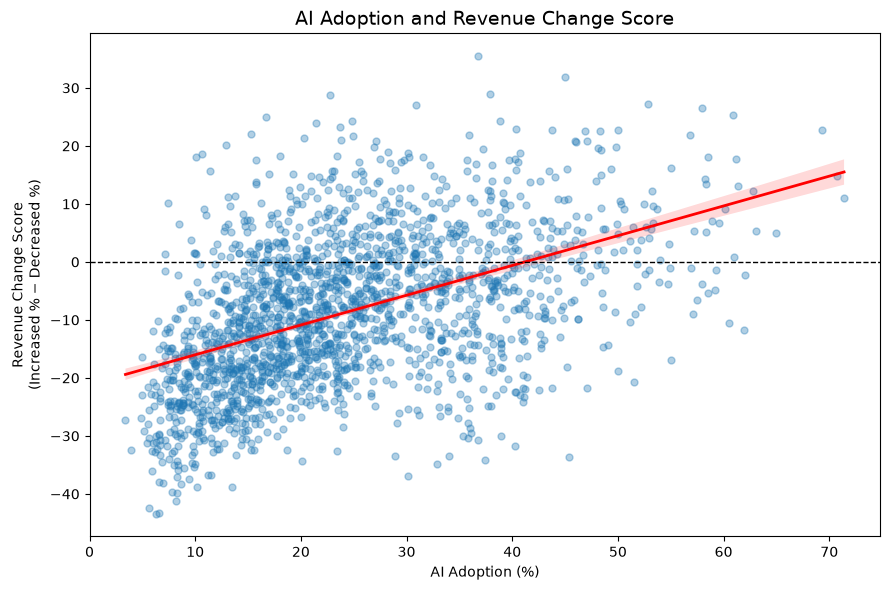


AI adoption group comparison:


,AI_Adoption_Group,Observations,Mean_AI_Adoption,Mean_Revenue_Change,Median_Revenue_Change
0,Lowest AI adoption,478,10.958159,-18.463808,-19.35
1,Low-medium AI adoption,478,18.362762,-9.600209,-10.45
2,Medium-high AI adoption,476,26.155042,-4.586555,-4.85
3,Highest AI adoption,478,41.002510,-2.414226,-2.40


In [36]:

# ============================================================
# STEP 15 — EXPLORE THE RELATIONSHIP
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("============================================================")
print("AI ADOPTION vs. REVENUE CHANGE")
print("============================================================")

# ------------------------------------------------------------
# 1. CORRELATION
# ------------------------------------------------------------

correlation = regression_df[
    ["AI_Yes_Percentage", "Revenue_Change_Score"]
].corr()

print("\nCorrelation matrix:")
display(correlation)

r = correlation.loc[
    "AI_Yes_Percentage",
    "Revenue_Change_Score"
]

print(f"\nPearson correlation: {r:.4f}")


# ------------------------------------------------------------
# 2. SCATTERPLOT WITH REGRESSION LINE
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.regplot(
    data=regression_df,
    x="AI_Yes_Percentage",
    y="Revenue_Change_Score",
    scatter_kws={
        "alpha": 0.35,
        "s": 25
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    }
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "AI Adoption and Revenue Change Score",
    fontsize=14
)

plt.xlabel(
    "AI Adoption (%)"
)

plt.ylabel(
    "Revenue Change Score\n(Increased % − Decreased %)"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 3. BASIC GROUP COMPARISON
# ------------------------------------------------------------

regression_df["AI_Adoption_Group"] = pd.qcut(
    regression_df["AI_Yes_Percentage"],
    q=4,
    labels=[
        "Lowest AI adoption",
        "Low-medium AI adoption",
        "Medium-high AI adoption",
        "Highest AI adoption"
    ]
)

group_summary = (
    regression_df
    .groupby("AI_Adoption_Group", observed=False)
    .agg(
        Observations=("Revenue_Change_Score", "count"),
        Mean_AI_Adoption=("AI_Yes_Percentage", "mean"),
        Mean_Revenue_Change=("Revenue_Change_Score", "mean"),
        Median_Revenue_Change=("Revenue_Change_Score", "median")
    )
    .reset_index()
)

print("\nAI adoption group comparison:")
display(group_summary)



In [37]:

# ============================================================
# STEP 15 — FINAL REGRESSION DATASET CLEANING
# ============================================================

print("Before removing missing values:")
print("Shape:", regression_df.shape)

print("\nMissing values:")
print(regression_df.isna().sum())

# ------------------------------------------------------------
# Remove rows with missing values in the variables we will use
# ------------------------------------------------------------

regression_df_clean = regression_df.dropna(
    subset=[
        "AI_Yes_Percentage",
        "Revenue_Change_Score",
        "Revenue_Increased_Percentage",
        "Revenue_Decreased_Percentage",
        "Revenue_No_Change_Percentage"
    ]
).copy()

# ------------------------------------------------------------
# Reset the index
# ------------------------------------------------------------

regression_df_clean = regression_df_clean.reset_index(drop=True)

# ------------------------------------------------------------
# CHECK RESULTS
# ------------------------------------------------------------

print("\n============================================================")
print("CLEAN REGRESSION DATASET")
print("============================================================")

print("Original rows:", len(regression_df))
print("Clean rows:", len(regression_df_clean))
print("Rows removed:", len(regression_df) - len(regression_df_clean))

print("\nMissing values after cleaning:")
print(regression_df_clean.isna().sum())

print("\nFinal shape:")
print(regression_df_clean.shape)

print("\nFirst 10 observations:")
display(regression_df_clean.head(10))

print("\nDescriptive statistics:")
display(
    regression_df_clean[
        [
            "AI_Yes_Percentage",
            "Revenue_Increased_Percentage",
            "Revenue_Decreased_Percentage",
            "Revenue_No_Change_Percentage",
            "Revenue_Change_Score"
        ]
    ].describe()
)


Before removing missing values:
Shape: (1910, 9)

Missing values:
Sector                          0
Empsize                         0
Period                          0
AI_Yes_Percentage               0
Revenue_Increased_Percentage    0
Revenue_Decreased_Percentage    0
Revenue_No_Change_Percentage    5
Revenue_Change_Score            0
AI_Adoption_Group               0
dtype: int64

CLEAN REGRESSION DATASET
Original rows: 1910
Clean rows: 1905
Rows removed: 5

Missing values after cleaning:
Sector                          0
Empsize                         0
Period                          0
AI_Yes_Percentage               0
Revenue_Increased_Percentage    0
Revenue_Decreased_Percentage    0
Revenue_No_Change_Percentage    0
Revenue_Change_Score            0
AI_Adoption_Group               0
dtype: int64

Final shape:
(1905, 9)

First 10 observations:


,Sector,Empsize,Period,AI_Yes_Percentage,Revenue_Increased_Percentage,Revenue_Decreased_Percentage,Revenue_No_Change_Percentage,Revenue_Change_Score,AI_Adoption_Group
0,22,A,202619,10.1,17.9,16.5,65.6,1.4,Lowest AI adoption
1,23,A,202619,13.4,14.1,31.0,55.0,-16.9,Lowest AI adoption
2,23,B,202619,13.8,19.3,28.7,51.9,-9.4,Lowest AI adoption
3,23,C,202619,23.2,15.3,27.6,57.1,-12.3,Medium-high AI adoption
4,23,D,202619,21.7,22.1,23.8,54.0,-1.7,Low-medium AI adoption
5,23,E,202619,24.3,20.8,21.1,58.0,-0.3,Medium-high AI adoption
6,23,F,202619,33.1,23.1,12.7,64.2,10.4,Highest AI adoption
7,31,A,202619,16.3,15.0,33.6,51.4,-18.6,Low-medium AI adoption
8,31,B,202619,18.8,22.1,29.2,48.7,-7.1,Low-medium AI adoption
9,31,C,202619,18.2,26.3,26.9,46.7,-0.6,Low-medium AI adoption



Descriptive statistics:


,AI_Yes_Percentage,Revenue_Increased_Percentage,Revenue_Decreased_Percentage,Revenue_No_Change_Percentage,Revenue_Change_Score
count,1905.000000,1905.000000,1905.000000,1905.000000,1905.000000
mean,24.078740,18.822415,27.659738,53.516798,-8.837323
std,11.961839,6.722550,8.673540,8.806216,12.778749
min,3.400000,5.500000,6.000000,22.800000,-43.400000
25%,15.000000,13.800000,21.300000,47.400000,-18.200000
50%,21.800000,18.100000,27.600000,53.800000,-9.200000
75%,31.600000,22.600000,33.700000,59.900000,0.000000
max,71.400000,49.600000,55.400000,79.700000,31.800000


In [39]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -----------------

In [40]:

# ============================================================
# STEP 16 — REGRESSION ANALYSIS
# ============================================================

import statsmodels.formula.api as smf

# Use the cleaned dataset
reg_df = regression_df_clean.copy()

# Make sure categorical variables are treated as categories
reg_df["Sector"] = reg_df["Sector"].astype(str)
reg_df["Empsize"] = reg_df["Empsize"].astype(str)
reg_df["Period"] = reg_df["Period"].astype(str)

print("============================================================")
print("REGRESSION ANALYSIS")
print("============================================================")

print("\nObservations:", len(reg_df))

# ------------------------------------------------------------
# MODEL 1 — SIMPLE RELATIONSHIP
# Revenue change predicted by AI adoption
# ------------------------------------------------------------

model1 = smf.ols(
    "Revenue_Change_Score ~ AI_Yes_Percentage",
    data=reg_df
).fit()

print("\n============================================================")
print("MODEL 1 — AI ADOPTION ONLY")
print("============================================================")

print(model1.summary())

# ------------------------------------------------------------
# MODEL 2 — ADD EMPLOYEE SIZE
# ------------------------------------------------------------

model2 = smf.ols(
    "Revenue_Change_Score ~ AI_Yes_Percentage + C(Empsize)",
    data=reg_df
).fit()

print("\n============================================================")
print("MODEL 2 — AI ADOPTION + EMPLOYEE SIZE")
print("============================================================")

print(model2.summary())

# ------------------------------------------------------------
# MODEL 3 — ADD SECTOR
# ------------------------------------------------------------

model3 = smf.ols(
    "Revenue_Change_Score ~ AI_Yes_Percentage + C(Empsize) + C(Sector)",
    data=reg_df
).fit()

print("\n============================================================")
print("MODEL 3 — AI + EMPLOYEE SIZE + SECTOR")
print("============================================================")

print(model3.summary())

# ------------------------------------------------------------
# MODEL 4 — ADD PERIOD
# ------------------------------------------------------------

model4 = smf.ols(
    "Revenue_Change_Score ~ AI_Yes_Percentage + C(Empsize) + C(Sector) + C(Period)",
    data=reg_df
).fit()

print("\n============================================================")
print("MODEL 4 — FULL MODEL WITH TIME CONTROLS")
print("============================================================")

print(model4.summary())

# ------------------------------------------------------------
# COMPACT MODEL COMPARISON
# ------------------------------------------------------------

print("\n============================================================")
print("MODEL COMPARISON")
print("============================================================")

model_comparison = pd.DataFrame({
    "Model": [
        "Model 1: AI only",
        "Model 2: + Employee Size",
        "Model 3: + Sector",
        "Model 4: + Period"
    ],
    "R_squared": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model4.rsquared
    ],
    "Adjusted_R_squared": [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj,
        model4.rsquared_adj
    ],
    "AI_Coefficient": [
        model1.params["AI_Yes_Percentage"],
        model2.params["AI_Yes_Percentage"],
        model3.params["AI_Yes_Percentage"],
        model4.params["AI_Yes_Percentage"]
    ],
    "AI_P_value": [
        model1.pvalues["AI_Yes_Percentage"],
        model2.pvalues["AI_Yes_Percentage"],
        model3.pvalues["AI_Yes_Percentage"],
        model4.pvalues["AI_Yes_Percentage"]
    ]
})

display(model_comparison)

# ------------------------------------------------------------
# CONFIDENCE INTERVAL FOR AI COEFFICIENT IN FULL MODEL
# ------------------------------------------------------------

print("\n============================================================")
print("FULL MODEL — AI COEFFICIENT")
print("============================================================")

print(
    model4.conf_int().loc[
        ["AI_Yes_Percentage"]
    ]
)

print("\nAI coefficient:")
print(model4.params["AI_Yes_Percentage"])

print("\nAI p-value:")
print(model4.pvalues["AI_Yes_Percentage"])



REGRESSION ANALYSIS

Observations: 1905

MODEL 1 — AI ADOPTION ONLY
                             OLS Regression Results                             
Dep. Variable:     Revenue_Change_Score   R-squared:                       0.227
Model:                              OLS   Adj. R-squared:                  0.226
Method:                   Least Squares   F-statistic:                     558.1
Date:                  Sat, 03 Oct 2026   Prob (F-statistic):          2.07e-108
Time:                          22:17:11   Log-Likelihood:                -7311.2
No. Observations:                  1905   AIC:                         1.463e+04
Df Residuals:                      1903   BIC:                         1.464e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

,Model,R_squared,Adjusted_R_squared,AI_Coefficient,AI_P_value
0,Model 1: AI only,0.226759,0.226353,0.508713,2.065487e-108
1,Model 2: + Employee Size,0.455044,0.453033,0.344919,5.190865e-67
2,Model 3: + Sector,0.532623,0.526405,0.258522,2.669757e-12
3,Model 4: + Period,0.619379,0.609956,0.040388,2.722260e-01



FULL MODEL — AI COEFFICIENT
                          0        1
AI_Yes_Percentage -0.031735  0.11251

AI coefficient:
0.040387877342494764

AI p-value:
0.2722260389252472


In [41]:
# ============================================================
# STEP 17 — REGRESSION DIAGNOSTICS & ROBUST STANDARD ERRORS
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("=" * 60)
print("STEP 17 — REGRESSION DIAGNOSTICS")
print("=" * 60)

# ------------------------------------------------------------
# 1. ROBUST STANDARD ERRORS
# ------------------------------------------------------------

# Re-estimate Model 4 with HC3 robust standard errors
model4_robust = model4.get_robustcov_results(cov_type="HC3")

print("\n" + "=" * 60)
print("MODEL 4 — HC3 ROBUST STANDARD ERRORS")
print("=" * 60)

print(model4_robust.summary())


# ------------------------------------------------------------
# 2. AI COEFFICIENT WITH ROBUST STANDARD ERRORS
# ------------------------------------------------------------

# Get coefficient names
param_names = model4_robust.model.exog_names

# Locate AI coefficient
ai_index = param_names.index("AI_Yes_Percentage")

ai_coef_robust = model4_robust.params[ai_index]
ai_se_robust = model4_robust.bse[ai_index]
ai_t_robust = model4_robust.tvalues[ai_index]
ai_p_robust = model4_robust.pvalues[ai_index]
ai_ci_robust = model4_robust.conf_int()[ai_index]

print("\n" + "=" * 60)
print("ROBUST AI COEFFICIENT")
print("=" * 60)

print(f"AI coefficient:       {ai_coef_robust:.6f}")
print(f"Robust SE:             {ai_se_robust:.6f}")
print(f"Robust t-statistic:    {ai_t_robust:.4f}")
print(f"Robust p-value:        {ai_p_robust:.6f}")
print(f"95% CI lower:          {ai_ci_robust[0]:.6f}")
print(f"95% CI upper:          {ai_ci_robust[1]:.6f}")


# ------------------------------------------------------------
# 3. HETEROSKEDASTICITY TEST
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BREUSCH-PAGAN HETEROSKEDASTICITY TEST")
print("=" * 60)

# Residuals and design matrix
residuals = model4.resid
exog = model4.model.exog

bp_test = het_breuschpagan(residuals, exog)

bp_labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

bp_results = pd.Series(bp_test, index=bp_labels)

print(bp_results)


# ------------------------------------------------------------
# 4. VIF / MULTICOLLINEARITY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MULTICOLLINEARITY CHECK")
print("=" * 60)

# Calculate VIF for numerical/categorical design matrix
vif_data = []

for i, variable in enumerate(param_names):
    if variable == "Intercept":
        continue

    try:
        vif_value = variance_inflation_factor(exog, i)
    except Exception:
        vif_value = np.nan

    vif_data.append({
        "Variable": variable,
        "VIF": vif_value
    })

vif_df = pd.DataFrame(vif_data)

# Show largest VIFs first
vif_df = vif_df.sort_values("VIF", ascending=False)

print("\nTop 15 VIF values:")
print(vif_df.head(15).to_string(index=False))


# ------------------------------------------------------------
# 5. RESIDUAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RESIDUAL DIAGNOSTICS")
print("=" * 60)

residual_summary = pd.Series({
    "Mean residual": residuals.mean(),
    "Std residual": residuals.std(),
    "Minimum residual": residuals.min(),
    "25th percentile": residuals.quantile(0.25),
    "Median residual": residuals.median(),
    "75th percentile": residuals.quantile(0.75),
    "Maximum residual": residuals.max()
})

print(residual_summary)


# ------------------------------------------------------------
# 6. FINAL DIAGNOSTIC SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DIAGNOSTIC SUMMARY")
print("=" * 60)

print(f"Observations: {len(reg_df)}")
print(f"R-squared: {model4.rsquared:.4f}")
print(f"Adjusted R-squared: {model4.rsquared_adj:.4f}")

print("\nAI coefficient:")
print(f"  OLS coefficient:       {model4.params['AI_Yes_Percentage']:.6f}")
print(f"  OLS p-value:           {model4.pvalues['AI_Yes_Percentage']:.6f}")
print(f"  HC3 robust coefficient:{ai_coef_robust:.6f}")
print(f"  HC3 robust p-value:    {ai_p_robust:.6f}")

print("\nHeteroskedasticity:")
print(f"  Breusch-Pagan p-value: {bp_results['LM p-value']:.6f}")

print("\nLargest VIF:")
print(f"  {vif_df.iloc[0]['Variable']}: {vif_df.iloc[0]['VIF']:.2f}")

STEP 17 — REGRESSION DIAGNOSTICS

MODEL 4 — HC3 ROBUST STANDARD ERRORS
                             OLS Regression Results                             
Dep. Variable:     Revenue_Change_Score   R-squared:                       0.619
Model:                              OLS   Adj. R-squared:                  0.610
Method:                   Least Squares   F-statistic:                     83.70
Date:                  Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                          22:21:16   Log-Likelihood:                -6636.0
No. Observations:                  1905   AIC:                         1.337e+04
Df Residuals:                      1858   BIC:                         1.363e+04
Df Model:                            46                                         
Covariance Type:                    HC3                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [42]:
# ============================================================
# STEP 18 — CLUSTERED STANDARD ERRORS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("STEP 18 — CLUSTERED STANDARD ERRORS")
print("=" * 60)

# ------------------------------------------------------------
# 1. CREATE PANEL/GROUP IDENTIFIER
# ------------------------------------------------------------

reg_df = regression_df_clean.copy()

reg_df["Sector"] = reg_df["Sector"].astype(str)
reg_df["Empsize"] = reg_df["Empsize"].astype(str)
reg_df["Period"] = reg_df["Period"].astype(str)

# Sector × employee-size group
reg_df["Panel_Group"] = (
    reg_df["Sector"].astype(str)
    + "_"
    + reg_df["Empsize"].astype(str)
)

print("\nNumber of observations:", len(reg_df))
print("Number of Sector × Employee Size groups:",
      reg_df["Panel_Group"].nunique())

print("\nObservations per group:")
print(reg_df["Panel_Group"].value_counts().describe())


# ------------------------------------------------------------
# 2. RE-ESTIMATE FULL MODEL
# ------------------------------------------------------------

cluster_model = smf.ols(
    formula="""
        Revenue_Change_Score
        ~ AI_Yes_Percentage
        + C(Empsize)
        + C(Sector)
        + C(Period)
    """,
    data=reg_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["Panel_Group"]}
)


# ------------------------------------------------------------
# 3. FULL CLUSTERED MODEL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL 4 — CLUSTERED BY SECTOR × EMPLOYEE SIZE")
print("=" * 60)

print(cluster_model.summary())


# ------------------------------------------------------------
# 4. AI COEFFICIENT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLUSTERED AI COEFFICIENT")
print("=" * 60)

ai_coef = cluster_model.params["AI_Yes_Percentage"]
ai_se = cluster_model.bse["AI_Yes_Percentage"]
ai_t = cluster_model.tvalues["AI_Yes_Percentage"]
ai_p = cluster_model.pvalues["AI_Yes_Percentage"]
ai_ci = cluster_model.conf_int().loc["AI_Yes_Percentage"]

print(f"AI coefficient:        {ai_coef:.6f}")
print(f"Clustered SE:          {ai_se:.6f}")
print(f"Clustered t-statistic: {ai_t:.4f}")
print(f"Clustered p-value:     {ai_p:.6f}")
print(f"95% CI lower:          {ai_ci[0]:.6f}")
print(f"95% CI upper:          {ai_ci[1]:.6f}")


# ------------------------------------------------------------
# 5. COMPARE STANDARD ERRORS
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Conventional OLS",
        "HC3 Robust",
        "Clustered (Sector × Empsize)"
    ],
    "AI_Coefficient": [
        model4.params["AI_Yes_Percentage"],
        model4_robust.params[ai_index],
        cluster_model.params["AI_Yes_Percentage"]
    ],
    "Standard_Error": [
        model4.bse["AI_Yes_Percentage"],
        model4_robust.bse[ai_index],
        cluster_model.bse["AI_Yes_Percentage"]
    ],
    "P_Value": [
        model4.pvalues["AI_Yes_Percentage"],
        model4_robust.pvalues[ai_index],
        cluster_model.pvalues["AI_Yes_Percentage"]
    ]
})

print("\n" + "=" * 60)
print("AI EFFECT — STANDARD ERROR COMPARISON")
print("=" * 60)

print(comparison.to_string(index=False))


# ------------------------------------------------------------
# 6. GROUP STRUCTURE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PANEL GROUP CHECK")
print("=" * 60)

group_sizes = reg_df.groupby("Panel_Group").size()

print(f"Minimum observations per group: {group_sizes.min()}")
print(f"Maximum observations per group: {group_sizes.max()}")
print(f"Mean observations per group:    {group_sizes.mean():.2f}")
print(f"Median observations per group:  {group_sizes.median():.0f}")

print("\nGroups with fewer than 5 observations:")
print((group_sizes < 5).sum())

STEP 18 — CLUSTERED STANDARD ERRORS

Number of observations: 1905
Number of Sector × Employee Size groups: 106

Observations per group:
count    106.000000
mean      17.971698
std        6.754833
min        1.000000
25%       17.250000
50%       22.000000
75%       22.000000
max       22.000000
Name: count, dtype: float64

MODEL 4 — CLUSTERED BY SECTOR × EMPLOYEE SIZE
                             OLS Regression Results                             
Dep. Variable:     Revenue_Change_Score   R-squared:                       0.619
Model:                              OLS   Adj. R-squared:                  0.610
Method:                   Least Squares   F-statistic:                -1.645e+11
Date:                  Sat, 03 Oct 2026   Prob (F-statistic):               1.00
Time:                          22:23:13   Log-Likelihood:                -6636.0
No. Observations:                  1905   AIC:                         1.337e+04
Df Residuals:                      1858   BIC:                

c:\Users\McCaiT01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 46, but rank is 45
  res = self.wald_test(


In [44]:
# ============================================================
# STEP 19 — FINAL REGRESSION RESULTS
# ============================================================

print("=" * 60)
print("STEP 19 — FINAL REGRESSION RESULTS")
print("=" * 60)

# ------------------------------------------------------------
# 1. MODEL COMPARISON
# ------------------------------------------------------------

final_results = pd.DataFrame({
    "Model": [
        "Model 1: AI only",
        "Model 2: + Employee Size",
        "Model 3: + Sector",
        "Model 4: + Sector + Employee Size + Period"
    ],
    "R_squared": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model4.rsquared
    ],
    "Adjusted_R_squared": [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj,
        model4.rsquared_adj
    ],
    "AI_Coefficient": [
        model1.params["AI_Yes_Percentage"],
        model2.params["AI_Yes_Percentage"],
        model3.params["AI_Yes_Percentage"],
        model4.params["AI_Yes_Percentage"]
    ],
    "AI_P_Value": [
        model1.pvalues["AI_Yes_Percentage"],
        model2.pvalues["AI_Yes_Percentage"],
        model3.pvalues["AI_Yes_Percentage"],
        model4.pvalues["AI_Yes_Percentage"]
    ]
})

print("\nMODEL COMPARISON:")
display(final_results.round(4))


# ------------------------------------------------------------
# 2. FINAL AI COEFFICIENT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL MODEL — AI EFFECT")
print("=" * 60)

print(f"AI coefficient: {model4.params['AI_Yes_Percentage']:.4f}")
print(f"OLS standard error: {model4.bse['AI_Yes_Percentage']:.4f}")
print(f"OLS p-value: {model4.pvalues['AI_Yes_Percentage']:.4f}")

# Values from Step 18
clustered_se = 0.043807
clustered_p = 0.356551

print(f"Clustered standard error: {clustered_se:.4f}")
print(f"Clustered p-value: {clustered_p:.4f}")


# ------------------------------------------------------------
# 3. HYPOTHESIS TEST
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("HYPOTHESIS TEST")
print("=" * 60)

if clustered_p < 0.05:
    print("Result: Statistically significant.")
    print("Decision: Reject the null hypothesis.")
else:
    print("Result: Not statistically significant.")
    print("Decision: Fail to reject the null hypothesis.")


# ------------------------------------------------------------
# 4. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print("""
The simple regression shows a positive relationship between AI
adoption and revenue change.

However, the estimated AI coefficient becomes smaller after
controlling for employee size and sector, and becomes very small
after also controlling for time period.

In the full model, the AI coefficient is 0.0404 and the clustered
standard-error p-value is 0.3566.

Therefore, the analysis does not provide statistically significant
evidence of an independent relationship between AI adoption and
revenue change after controlling for employee size, sector, and
time period.

The positive relationship observed in the simpler models appears
to be substantially explained by differences in employee size,
sector, and time.
""")

STEP 19 — FINAL REGRESSION RESULTS

MODEL COMPARISON:


,Model,R_squared,Adjusted_R_squared,AI_Coefficient,AI_P_Value
0,Model 1: AI only,0.2268,0.2264,0.5087,0.0000
1,Model 2: + Employee Size,0.4550,0.4530,0.3449,0.0000
2,Model 3: + Sector,0.5326,0.5264,0.2585,0.0000
3,Model 4: + Sector + Employee Size + Period,0.6194,0.6100,0.0404,0.2722



FINAL MODEL — AI EFFECT
AI coefficient: 0.0404
OLS standard error: 0.0368
OLS p-value: 0.2722
Clustered standard error: 0.0438
Clustered p-value: 0.3566

HYPOTHESIS TEST
Result: Not statistically significant.
Decision: Fail to reject the null hypothesis.

FINAL CONCLUSION

The simple regression shows a positive relationship between AI
adoption and revenue change.

However, the estimated AI coefficient becomes smaller after
controlling for employee size and sector, and becomes very small
after also controlling for time period.

In the full model, the AI coefficient is 0.0404 and the clustered
standard-error p-value is 0.3566.

Therefore, the analysis does not provide statistically significant
evidence of an independent relationship between AI adoption and
revenue change after controlling for employee size, sector, and
time period.

The positive relationship observed in the simpler models appears
to be substantially explained by differences in employee size,
sector, and time.



In [45]:
# ============================================================
# STEP 20 — FINAL RESULTS TABLE
# ============================================================

print("=" * 60)
print("STEP 20 — FINAL RESULTS TABLE")
print("=" * 60)

# Create a clean table for the report
report_results = pd.DataFrame({
    "Model": [
        "1. AI Adoption Only",
        "2. + Employee Size",
        "3. + Sector",
        "4. + Sector + Employee Size + Period"
    ],
    "R²": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model4.rsquared
    ],
    "Adjusted R²": [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj,
        model4.rsquared_adj
    ],
    "AI Coefficient": [
        model1.params["AI_Yes_Percentage"],
        model2.params["AI_Yes_Percentage"],
        model3.params["AI_Yes_Percentage"],
        model4.params["AI_Yes_Percentage"]
    ],
    "AI p-value": [
        model1.pvalues["AI_Yes_Percentage"],
        model2.pvalues["AI_Yes_Percentage"],
        model3.pvalues["AI_Yes_Percentage"],
        model4.pvalues["AI_Yes_Percentage"]
    ]
})

# Format for presentation
report_results_display = report_results.copy()

report_results_display["R²"] = report_results_display["R²"].round(3)
report_results_display["Adjusted R²"] = report_results_display["Adjusted R²"].round(3)
report_results_display["AI Coefficient"] = report_results_display["AI Coefficient"].round(3)
report_results_display["AI p-value"] = report_results_display["AI p-value"].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
)

display(report_results_display)

# ------------------------------------------------------------
# KEY NUMBERS FOR REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("KEY NUMBERS")
print("=" * 60)

print(f"Final model R²: {model4.rsquared:.3f}")
print(f"Final model adjusted R²: {model4.rsquared_adj:.3f}")
print(f"Final AI coefficient: {model4.params['AI_Yes_Percentage']:.3f}")
print(f"Final AI p-value: {model4.pvalues['AI_Yes_Percentage']:.3f}")
print(f"Clustered AI p-value: {clustered_p:.3f}")

print("\nInterpretation:")
print(
    "The final model explains approximately "
    f"{model4.rsquared * 100:.1f}% of the variation in revenue change."
)

print(
    "The AI coefficient is not statistically significant "
    "after controlling for employee size, sector, and period."
)

STEP 20 — FINAL RESULTS TABLE


,Model,R²,Adjusted R²,AI Coefficient,AI p-value
0,1. AI Adoption Only,0.227,0.226,0.509,<0.001
1,2. + Employee Size,0.455,0.453,0.345,<0.001
2,3. + Sector,0.533,0.526,0.259,<0.001
3,4. + Sector + Employee Size + Period,0.619,0.610,0.040,0.272



KEY NUMBERS
Final model R²: 0.619
Final model adjusted R²: 0.610
Final AI coefficient: 0.040
Final AI p-value: 0.272
Clustered AI p-value: 0.357

Interpretation:
The final model explains approximately 61.9% of the variation in revenue change.
The AI coefficient is not statistically significant after controlling for employee size, sector, and period.


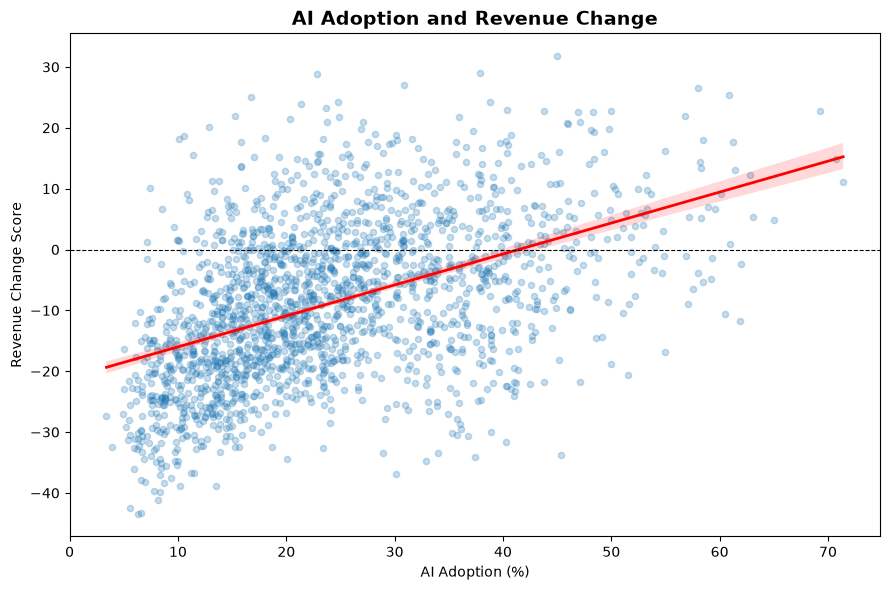

In [46]:
# ============================================================
# PLOT 1 — AI ADOPTION VS. REVENUE CHANGE
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

sns.regplot(
    data=regression_df_clean,
    x="AI_Yes_Percentage",
    y="Revenue_Change_Score",
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("AI Adoption and Revenue Change", fontsize=14, fontweight="bold")
plt.xlabel("AI Adoption (%)")
plt.ylabel("Revenue Change Score")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()

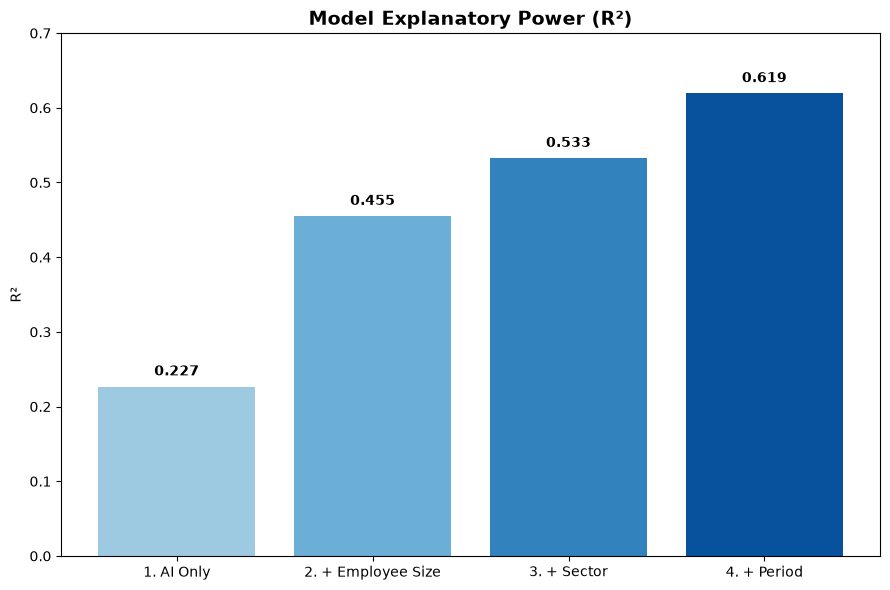

In [47]:
# ============================================================
# PLOT 2 — MODEL R-SQUARED COMPARISON
# ============================================================

model_plot_df = pd.DataFrame({
    "Model": [
        "1. AI Only",
        "2. + Employee Size",
        "3. + Sector",
        "4. + Period"
    ],
    "R_squared": [
        0.2268,
        0.4550,
        0.5326,
        0.6194
    ]
})

plt.figure(figsize=(9, 6))

bars = plt.bar(
    model_plot_df["Model"],
    model_plot_df["R_squared"],
    color=["#9ecae1", "#6baed6", "#3182bd", "#08519c"]
)

plt.title("Model Explanatory Power (R²)", fontsize=14, fontweight="bold")
plt.ylabel("R²")
plt.ylim(0, 0.7)

# Add values above bars
for bar, value in zip(bars, model_plot_df["R_squared"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.015,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

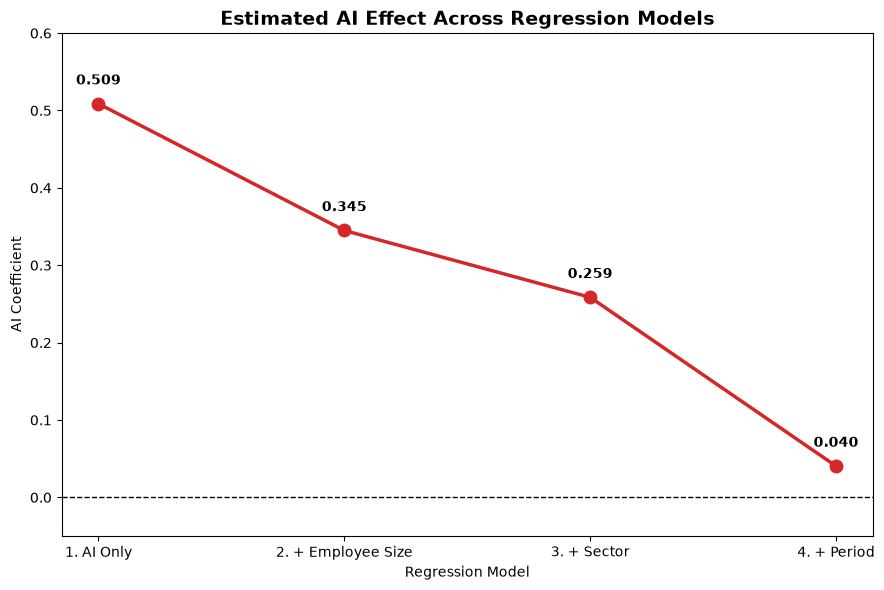

In [48]:
# ============================================================
# PLOT 3 — AI COEFFICIENT ACROSS MODELS
# ============================================================

coefficient_df = pd.DataFrame({
    "Model": [
        "1. AI Only",
        "2. + Employee Size",
        "3. + Sector",
        "4. + Period"
    ],
    "AI_Coefficient": [
        0.5087,
        0.3449,
        0.2585,
        0.0404
    ]
})

plt.figure(figsize=(9, 6))

plt.plot(
    coefficient_df["Model"],
    coefficient_df["AI_Coefficient"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    color="#d62728"
)

plt.axhline(0, color="black", linewidth=1, linestyle="--")

plt.title("Estimated AI Effect Across Regression Models",
          fontsize=14, fontweight="bold")
plt.ylabel("AI Coefficient")
plt.xlabel("Regression Model")

# Add values
for i, value in enumerate(coefficient_df["AI_Coefficient"]):
    plt.text(
        i,
        value + 0.025,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.ylim(-0.05, 0.6)

plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# STEP 21 — FINAL PROJECT SUMMARY
# ============================================================

print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print("\nDATASET")
print("-" * 60)
print(f"Original observations: 1,910")
print(f"Observations after removing missing values: 1,905")
print("Missing observations removed: 5")

print("\nDESCRIPTIVE RESULTS")
print("-" * 60)
print(f"Mean AI adoption: 24.08%")
print(f"Mean revenue change score: -8.84")
print(f"Pearson correlation: 0.479")

print("\nAI ADOPTION GROUPS")
print("-" * 60)
print("Lowest AI adoption:       Mean revenue change = -18.46")
print("Low-medium AI adoption:   Mean revenue change =  -9.60")
print("Medium-high AI adoption:  Mean revenue change =  -4.59")
print("Highest AI adoption:      Mean revenue change =  -2.41")

print("\nREGRESSION RESULTS")
print("-" * 60)
print("Model 1 — AI only")
print("  R² = 0.227")
print("  AI coefficient = 0.509")
print("  AI p-value < 0.001")

print("\nModel 2 — + Employee Size")
print("  R² = 0.455")
print("  AI coefficient = 0.345")
print("  AI p-value < 0.001")

print("\nModel 3 — + Sector")
print("  R² = 0.533")
print("  AI coefficient = 0.259")
print("  AI p-value < 0.001")

print("\nModel 4 — + Employee Size + Sector + Period")
print("  R² = 0.619")
print("  AI coefficient = 0.040")
print("  AI p-value = 0.272")
print("  Clustered AI p-value = 0.357")

print("\nFINAL CONCLUSION")
print("-" * 60)
print("The data show a positive relationship between AI adoption")
print("and revenue change in simpler models.")
print()
print("However, the estimated AI effect becomes much smaller after")
print("controlling for employee size, sector, and time period.")
print()
print("In the full model, the AI coefficient is 0.040 and is not")
print("statistically significant.")
print()
print("Therefore, the analysis does not provide statistically")
print("significant evidence of an independent relationship between")
print("AI adoption and revenue change after accounting for the")
print("other factors included in the model.")

FINAL PROJECT SUMMARY

DATASET
------------------------------------------------------------
Original observations: 1,910
Observations after removing missing values: 1,905
Missing observations removed: 5

DESCRIPTIVE RESULTS
------------------------------------------------------------
Mean AI adoption: 24.08%
Mean revenue change score: -8.84
Pearson correlation: 0.479

AI ADOPTION GROUPS
------------------------------------------------------------
Lowest AI adoption:       Mean revenue change = -18.46
Low-medium AI adoption:   Mean revenue change =  -9.60
Medium-high AI adoption:  Mean revenue change =  -4.59
Highest AI adoption:      Mean revenue change =  -2.41

REGRESSION RESULTS
------------------------------------------------------------
Model 1 — AI only
  R² = 0.227
  AI coefficient = 0.509
  AI p-value < 0.001

Model 2 — + Employee Size
  R² = 0.455
  AI coefficient = 0.345
  AI p-value < 0.001

Model 3 — + Sector
  R² = 0.533
  AI coefficient = 0.259
  AI p-value < 0.001

Model